Dataset Loaded Successfully!

--- Shape ---
(112, 14)

--- Data Types ---
circuit_key            int64
circuit_short_name    object
country_code          object
country_key            int64
country_name          object
date_end              object
date_start            object
gmt_offset            object
location              object
meeting_key            int64
session_key            int64
session_name          object
session_type          object
year                   int64
dtype: object

--- Summary Statistics ---
        circuit_key circuit_short_name country_code  country_key  \
count    112.000000                112          112   112.000000   
unique          NaN                 22           20          NaN   
top             NaN             Sakhir          USA          NaN   
freq            NaN                  8           15          NaN   
mean      58.214286                NaN          NaN    44.830357   
std       53.381920                NaN          NaN    53.524919   
mi

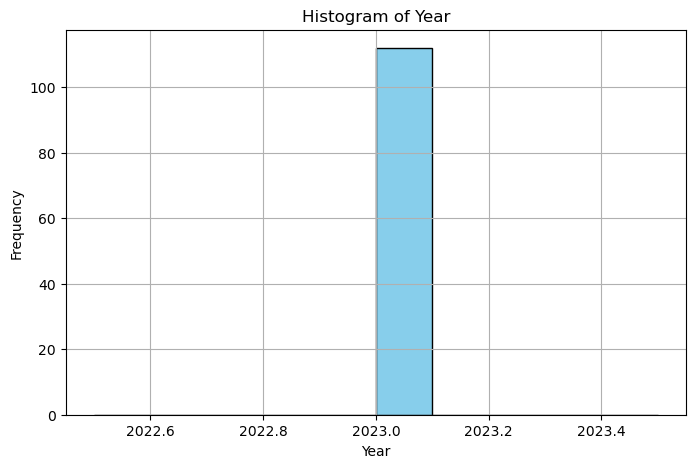

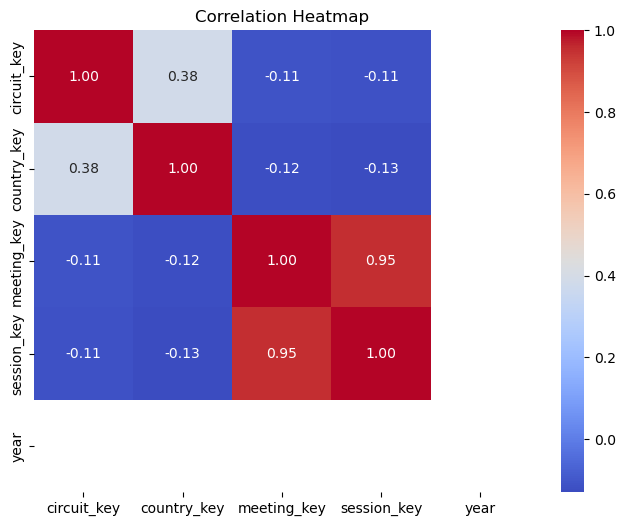


--- Mean (Numeric Only) ---
circuit_key      58.214286
country_key      44.830357
meeting_key    1204.839286
session_key    8949.035714
year           2023.000000
dtype: float64

--- Median (Numeric Only) ---
circuit_key      46.0
country_key      19.0
meeting_key    1215.0
session_key    9140.5
year           2023.0
dtype: float64

--- Label Encoding (Session Type) ---
  session_type  session_type_label
0     Practice                   0
1     Practice                   0
2     Practice                   0
3     Practice                   0
4     Practice                   0

--- One-Hot Encoding (Country Name) ---
   country_name_Australia  country_name_Austria  country_name_Azerbaijan  \
0                       0                     0                        0   
1                       0                     0                        0   
2                       0                     0                        0   
3                       0                     0                        

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# ==================================================
# Fix Path Issue (แก้ปัญหาหาไฟล์ไม่เจอใน VS Code Notebook)
# ==================================================
# ถ้าโฟลเดอร์ปัจจุบันไม่ใช่ LAB02 ให้เปลี่ยนเข้าไปที่ LAB02
if "LAB02" not in os.getcwd():
    try:
        os.chdir("LAB02")
    except FileNotFoundError:
        pass # ปล่อยผ่านถ้าอยู่ในโฟลเดอร์ที่ถูกต้องอยู่แล้ว

# ==================================================
# Load Dataset
# ==================================================
# โหลดข้อมูลดิบ
df = pd.read_csv("sessions.csv")

print("="*50)
print("Dataset Loaded Successfully!")
print("="*50)

# ==================================================
# LAB 1: Dataset Exploration
# ==================================================
print("\n--- Shape ---")
print(df.shape)

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Summary Statistics ---")
print(df.describe(include='all'))

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Records ---")
print(df.duplicated().sum())

print("\n--- Session Type Distribution ---")
print(df["session_type"].value_counts())

# ==================================================
# LAB 2: Data Visualization
# ==================================================
# 1. Histogram of Year
plt.figure(figsize=(8,5))
df["year"].hist(bins=10, color='skyblue', edgecolor='black')
plt.title("Histogram of Year")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

# 2. Correlation Heatmap
# เลือกเฉพาะคอลัมน์ที่เป็นตัวเลขเพื่อนำมาพล็อต Heatmap
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# ==================================================
# Part 3: Data Cleaning
# ==================================================
# Remove duplicates (ลบข้อมูลซ้ำ)
df = df.drop_duplicates()

# Fill missing values (จัดการค่าว่าง)
for col in df.columns:
    if df[col].dtype == "object":
        # ถ้าเป็นตัวหนังสือ ให้เติมคำว่า "Unknown"
        df[col] = df[col].fillna("Unknown")
    else:
        # ถ้าเป็นตัวเลข ให้เติมด้วยค่า Median
        df[col] = df[col].fillna(df[col].median())

# Incorrect Data Correction (ลบช่องว่างส่วนเกินหน้า/หลังตัวหนังสือ)
df["country_name"] = df["country_name"].str.strip()

# Data Type Conversion (แปลงชนิดข้อมูลปีเป็นจำนวนเต็ม)
df["year"] = df["year"].astype(int)

# ==================================================
# Mean & Median (หลังทำความสะอาดข้อมูล)
# ==================================================
print("\n--- Mean (Numeric Only) ---")
print(df.mean(numeric_only=True))

print("\n--- Median (Numeric Only) ---")
print(df.median(numeric_only=True))

# ==================================================
# Part 4: Feature Engineering
# ==================================================
# 1. Label Encoding
le = LabelEncoder()
df["session_type_label"] = le.fit_transform(df["session_type"])

print("\n--- Label Encoding (Session Type) ---")
print(df[["session_type","session_type_label"]].head())

# 2. One-Hot Encoding
onehot = pd.get_dummies(df, columns=["country_name"], dtype=int)

print("\n--- One-Hot Encoding (Country Name) ---")
# แสดงตัวอย่างแค่ 5 แถว และคอลัมน์ที่ขึ้นต้นด้วย country_name_
encoded_cols = [col for col in onehot.columns if 'country_name_' in col]
print(onehot[encoded_cols].head())

# ==================================================
# Save Cleaned Data
# ==================================================
# บันทึกไฟล์ที่คลีนแล้ว
df.to_csv("sessions_clean.csv", index=False)

print("\n" + "="*50)
print("Finished! Saved as sessions_clean.csv")
print("="*50)